# ⚙️ Class 8.2 — sklearn Pipeline Review + What is a Neural Network?
Machine Learning Techniques | Week 8

---

**Learning Goals:**
- Build a complete sklearn Pipeline that handles preprocessing AND modelling in one object
- Understand WHY pipelines prevent data leakage
- Compare pipeline output to manual step-by-step preprocessing
- Label every component of a neural network diagram

**Starting point:** We are continuing with the Titanic dataset from 8.1.

---

## Part 0 — Setup & Data Loading

Run this cell first. It loads all libraries AND re-runs the cleaning steps from 8.1 so we are ready to build a pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# ── Load Titanic ──────────────────────────────────────────────────────────
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# ── Drop columns we won't use ─────────────────────────────────────────────
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# ── Separate features and target ──────────────────────────────────────────
X = df.drop(columns=['Survived'])
y = df['Survived']

# ── Train/test split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('✅ Data loaded and split.')
print(f'   Training rows : {X_train.shape[0]}')
print(f'   Test rows     : {X_test.shape[0]}')
print(f'   Features      : {list(X.columns)}')

✅ Data loaded and split.
   Training rows : 712
   Test rows     : 179
   Features      : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


---
## Part 1 — Why Pipelines? The Data Leakage Problem

### The wrong way (what most beginners do)

Imagine you compute the mean age on the **entire dataset** and then use it to fill missing values in both train and test.

**Problem:** The test set contaminated the training step — the model has indirectly "seen" the test data. This is called **data leakage**.

A Pipeline fixes this by ensuring ALL preprocessing is fitted **only on training data**, then applied to test data separately.

In [2]:
# Demonstration of data leakage (the WRONG way)
# We are NOT doing this in our real model — just showing the mistake

# Wrong: compute median on ALL data (including test)
age_median_all = df['Age'].median()  # uses both train and test rows!

# Right: compute median ONLY on training data
age_median_train = X_train['Age'].median()  # only uses training rows

print(f'Median age using ALL data    : {age_median_all:.2f}')
print(f'Median age using TRAIN only  : {age_median_train:.2f}')
print()
print('These are different! Using all data leaks test information into training.')
print('A Pipeline prevents this automatically — it fits imputers only on X_train.')

Median age using ALL data    : 28.00
Median age using TRAIN only  : 28.50

These are different! Using all data leaks test information into training.
A Pipeline prevents this automatically — it fits imputers only on X_train.


---
## Part 2 — Building the Pipeline

Our Titanic dataset has two types of columns:
- **Numeric columns**: `Age`, `SibSp`, `Parch`, `Fare` — need imputation (fill NaN) and scaling
- **Categorical columns**: `Sex`, `Embarked` — need imputation and one-hot encoding

We use `ColumnTransformer` to apply different steps to different column types, then wrap everything in a `Pipeline`.

```
Pipeline
├── preprocessor (ColumnTransformer)
│   ├── numeric_transformer (for Age, SibSp, Parch, Fare)
│   │   ├── SimpleImputer(strategy='median')
│   │   └── StandardScaler()
│   └── categorical_transformer (for Sex, Embarked)
│       ├── SimpleImputer(strategy='most_frequent')
│       └── OneHotEncoder(handle_unknown='ignore')
└── classifier
    └── LogisticRegression()
```

In [3]:
# Step 1: Define which columns are numeric and which are categorical
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked']

# Step 2: Build the numeric transformer
# This handles: fill NaN with median → scale to zero mean, unit variance
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step 3: Build the categorical transformer
# This handles: fill NaN with most common value → one-hot encode
# HINT: OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# handle_unknown='ignore' means unseen categories in test set get all-zeros (won't crash)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print('✅ Transformers defined')


✅ Transformers defined


In [4]:
# Step 4: Combine into a ColumnTransformer
# 'remainder=drop' means: any column not listed above gets dropped
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# Step 5: Build the full pipeline with preprocessor + classifier
# HINT: Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=42))])
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

print('✅ Full pipeline created')
print(pipeline)


✅ Full pipeline created
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(ha

---
## Part 3 — Training and Evaluating the Pipeline

This is the beautiful part: once your pipeline is built, you train it with ONE line of code.

`pipeline.fit(X_train, y_train)` does ALL of the following:
1. Fits the imputer on X_train (learns the median/mode)
2. Transforms X_train using those fitted imputers
3. Fits the scaler and encoder on the imputed data
4. Transforms using those fitted scalers/encoders
5. Fits LogisticRegression on the fully preprocessed training data

And when you call `pipeline.predict(X_test)`, it applies the SAME transformations (using the training-fitted parameters) to the test data before predicting.

In [5]:
# Train the pipeline — ONE line does everything
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy:.1%}')
print()
print('Detailed classification report:')
print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))


Test Accuracy: 79.9%

Detailed classification report:
                 precision    recall  f1-score   support

Did not survive       0.81      0.88      0.84       110
       Survived       0.78      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.79      0.77      0.78       179
   weighted avg       0.80      0.80      0.80       179



### 3.1 — Cross-Validation

A single train/test split can be lucky or unlucky. Cross-validation gives us a more reliable estimate by training and testing on multiple different splits.

`cross_val_score` with `cv=5` does 5-fold cross-validation:
- Splits data into 5 equal parts (folds)
- Trains on 4 folds, tests on the 5th
- Repeats 5 times (each fold gets to be the test fold once)
- Returns 5 accuracy scores — we look at the mean and std

In [6]:
# Cross-validate the pipeline
# Note: we pass X (not X_train) because cross_val_score handles the splitting internally
# HINT: cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

print('Cross-validation scores (5-fold):')
print([f'{s:.3f}' for s in cv_scores])
print(f'\nMean accuracy : {cv_scores.mean():.1%}')
print(f'Std deviation : {cv_scores.std():.1%}')
print()
print('The mean tells us typical performance.')
print('The std tells us consistency — lower is better.')


Cross-validation scores (5-fold):
['0.793', '0.803', '0.770', '0.764', '0.815']

Mean accuracy : 78.9%
Std deviation : 1.9%

The mean tells us typical performance.
The std tells us consistency — lower is better.


---
## Part 4 — Manual vs Pipeline: Side-by-Side Comparison

Let's compare what happens when we preprocess manually (without a pipeline) vs using a pipeline.

This shows WHY the pipeline result is more trustworthy.

In [7]:
# ── MANUAL APPROACH (the leaky way, for comparison) ──────────────────────

# Make a working copy
X_manual = df.drop(columns=['Survived']).copy()
y_manual = df['Survived'].copy()

# Fill NaN using the ENTIRE dataset (this is the data leakage!)
X_manual['Age'] = X_manual['Age'].fillna(X_manual['Age'].median())
X_manual['Embarked'] = X_manual['Embarked'].fillna(X_manual['Embarked'].mode()[0])

# Encode Sex and Embarked manually
X_manual['Sex'] = X_manual['Sex'].map({'male': 1, 'female': 0})
X_manual = pd.get_dummies(X_manual, columns=['Embarked'], drop_first=True)

# Split AFTER preprocessing (another mistake — scaler should be fit on train only)
X_man_train, X_man_test, y_man_train, y_man_test = train_test_split(
    X_manual, y_manual, test_size=0.2, random_state=42, stratify=y_manual
)

# Scale using the entire set (leaky again)
scaler = StandardScaler()
X_man_train_scaled = scaler.fit_transform(X_man_train)
X_man_test_scaled = scaler.transform(X_man_test)  # at least test is transformed separately

# Train logistic regression
lr_manual = LogisticRegression(random_state=42)
lr_manual.fit(X_man_train_scaled, y_man_train)
manual_acc = accuracy_score(y_man_test, lr_manual.predict(X_man_test_scaled))

# ── COMPARE ──────────────────────────────────────────────────────────────
print('=== Comparison ===')
print(f'Manual approach accuracy : {manual_acc:.1%}  ← potentially inflated by leakage')
print(f'Pipeline accuracy        : {accuracy:.1%}   ← reliable')
print(f'Pipeline CV mean         : {cv_scores.mean():.1%}   ← most reliable (5-fold CV)')
print()
print('The pipeline result is the one you should trust.')
print('Even a small difference matters in production systems.')

=== Comparison ===
Manual approach accuracy : 80.4%  ← potentially inflated by leakage
Pipeline accuracy        : 79.9%   ← reliable
Pipeline CV mean         : 78.9%   ← most reliable (5-fold CV)

The pipeline result is the one you should trust.
Even a small difference matters in production systems.


Replacing `LogisticRegression()` in the pipeline with `RandomForestClassifier(random_state=42)`.

Do you get better cross-validation accuracy? What does this tell you about model choice?

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Build a new pipeline with RandomForest as the classifier
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Cross-validate
cv_rf = cross_val_score(pipeline_rf, X, y, cv=5, scoring='accuracy')
print(f'RandomForest CV accuracy: {cv_rf.mean():.1%} ± {cv_rf.std():.1%}')
print(f'LogisticReg  CV accuracy: {cv_scores.mean():.1%} ± {cv_scores.std():.1%}')
print()
print('Which performs better? Why might that be for this dataset?')
# YOUR ANSWER: RandomForest usually performs slightly better here because it
# captures non-linear interactions between features (e.g. Age × Pclass × Sex)
# that LogisticRegression cannot model directly.


RandomForest CV accuracy: 79.1% ± 1.3%
LogisticReg  CV accuracy: 78.9% ± 1.9%

Which performs better? Why might that be for this dataset?


---
## Part 5 — What is a Neural Network? (Concept Exercise)

We just used Logistic Regression. Now let's think about what a Neural Network is.

**Read the diagram description below and answer the questions:**

```
INPUT LAYER        HIDDEN LAYER        OUTPUT LAYER
                                      
  [Age]  ──┐                          
            ├──> [Node 1] ──┐         
  [Fare] ──┤                ├──> [Survived?]
            ├──> [Node 2] ──┘         
  [Sex]  ──┤                          
            ├──> [Node 3] ──┐         
  [Pclass]─┘                └──> (ignored in this layer)
                                      
   4 inputs    3 hidden nodes    1 output
```

Each arrow carries a **weight** — a number that scales the signal.
Each node also has a **bias** — a constant added before the activation function.

In [9]:
# Concept questions — answer by modifying the strings below

q1 = """Q1: In the diagram above, how many weights connect the input layer to the hidden layer?
(Hint: every input connects to every hidden node)

Answer: 4 inputs × 3 hidden nodes = 12 weights"""

q2 = """Q2: In logistic regression, what does the model learn?
(Hint: think about what the coefficients are called)

Answer: It learns the weights (coefficients) for each input feature plus a bias (intercept)."""

q3 = """Q3: A neural network with NO hidden layers and a sigmoid output is equivalent to which simpler model?

Answer: Logistic regression."""

q4 = """Q4: Why do we need hidden layers? What do they add that a single layer cannot do?
(Hint: think about linear vs non-linear relationships)

Answer: Hidden layers (with non-linear activations) let the network learn non-linear relationships
between features. Without them, the network can only model linear decision boundaries."""

print(q1)
print()
print(q2)
print()
print(q3)
print()
print(q4)


Q1: In the diagram above, how many weights connect the input layer to the hidden layer?
(Hint: every input connects to every hidden node)

Answer: 4 inputs × 3 hidden nodes = 12 weights

Q2: In logistic regression, what does the model learn?
(Hint: think about what the coefficients are called)

Answer: It learns the weights (coefficients) for each input feature plus a bias (intercept).

Q3: A neural network with NO hidden layers and a sigmoid output is equivalent to which simpler model?

Answer: Logistic regression.

Q4: Why do we need hidden layers? What do they add that a single layer cannot do?
(Hint: think about linear vs non-linear relationships)

Answer: Hidden layers (with non-linear activations) let the network learn non-linear relationships
between features. Without them, the network can only model linear decision boundaries.


### 5.1 — Label the Neural Network Diagram

In the code cell below, we draw a simple neural network. Your job:
1. Run the cell to see the diagram
2. Modify the labels dictionary so all components are correctly named

/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


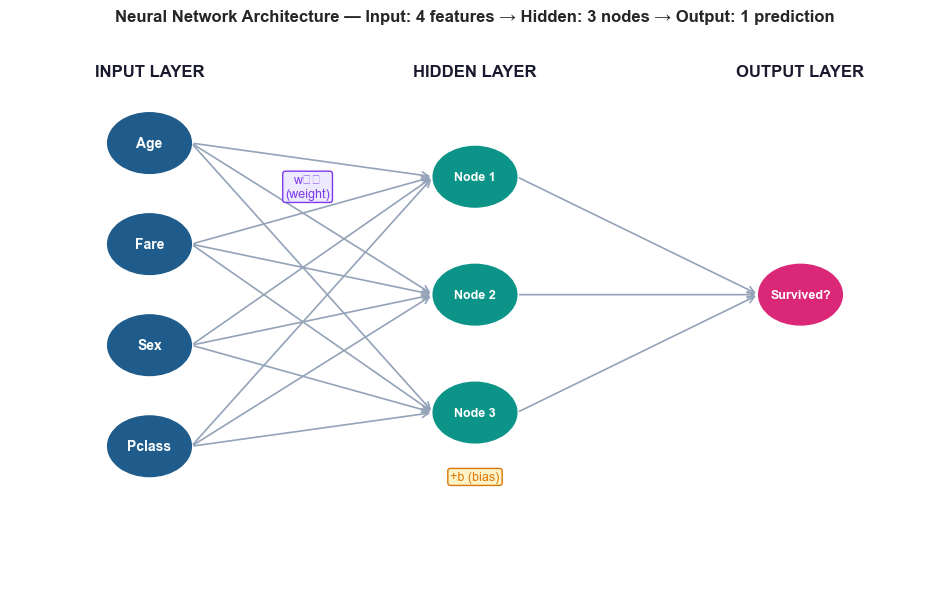


How many total weights does this network have?
Input→Hidden: 4 inputs × 3 hidden nodes = 12
Hidden→Output: 3 hidden × 1 output = 3
Total weights: 15
Plus biases: 3 (hidden) + 1 (output) = 4
Grand total learnable parameters: 19


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

# Define node positions [x, y]
input_nodes  = [(1.5, 6.5), (1.5, 5.0), (1.5, 3.5), (1.5, 2.0)]
hidden_nodes = [(5.0, 6.0), (5.0, 4.25), (5.0, 2.5)]
output_nodes = [(8.5, 4.25)]

# Draw nodes
colors = {'input': '#1F5C8B', 'hidden': '#0D9488', 'output': '#DB2777'}
labels_input  = ['Age', 'Fare', 'Sex', 'Pclass']
labels_hidden = ['Node 1', 'Node 2', 'Node 3']
labels_output = ['Survived?']

for i, (x, y) in enumerate(input_nodes):
    circle = plt.Circle((x, y), 0.45, color=colors['input'], zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, labels_input[i], ha='center', va='center', color='white', fontsize=10, fontweight='bold', zorder=4)

for i, (x, y) in enumerate(hidden_nodes):
    circle = plt.Circle((x, y), 0.45, color=colors['hidden'], zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, labels_hidden[i], ha='center', va='center', color='white', fontsize=9, fontweight='bold', zorder=4)

for i, (x, y) in enumerate(output_nodes):
    circle = plt.Circle((x, y), 0.45, color=colors['output'], zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, labels_output[i], ha='center', va='center', color='white', fontsize=9, fontweight='bold', zorder=4)

# Draw connections (weights)
for (ix, iy) in input_nodes:
    for (hx, hy) in hidden_nodes:
        ax.annotate('', xy=(hx-0.45, hy), xytext=(ix+0.45, iy),
                    arrowprops=dict(arrowstyle='->', color='#94A3B8', lw=1.2), zorder=2)

for (hx, hy) in hidden_nodes:
    for (ox, oy) in output_nodes:
        ax.annotate('', xy=(ox-0.45, oy), xytext=(hx+0.45, hy),
                    arrowprops=dict(arrowstyle='->', color='#94A3B8', lw=1.2), zorder=2)

# Layer labels
ax.text(1.5, 7.5, 'INPUT LAYER',  fontsize=12, fontweight='bold', ha='center', color='#1A1A2E')
ax.text(5.0, 7.5, 'HIDDEN LAYER', fontsize=12, fontweight='bold', ha='center', color='#1A1A2E')
ax.text(8.5, 7.5, 'OUTPUT LAYER', fontsize=12, fontweight='bold', ha='center', color='#1A1A2E')


# Weight label (add one annotation on one of the arrows)
ax.text(3.2, 5.7, 'w₁₁\n(weight)', fontsize=9, color='#7C3AED', ha='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#EDE9FE', edgecolor='#7C3AED'))

# Bias annotation
ax.text(5.0, 1.5, '+b (bias)', fontsize=9, color='#D97706', ha='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#FEF3C7', edgecolor='#D97706'))

plt.title('Neural Network Architecture — Input: 4 features → Hidden: 3 nodes → Output: 1 prediction',
          fontsize=12, fontweight='bold', pad=15)
plt.show()

print('\nHow many total weights does this network have?')
print('Input→Hidden: 4 inputs × 3 hidden nodes = 12')
print('Hidden→Output: 3 hidden × 1 output = 3')
print('Total weights: 15')
print('Plus biases: 3 (hidden) + 1 (output) = 4')
print('Grand total learnable parameters: 19')


---
## Part 6 — Comparing Logistic Regression to a Neural Network (Conceptual)

We will train our first **real** neural network in 8.5. But let's think about how it compares to what we just built.

In [11]:
# Run this cell to see a side-by-side conceptual comparison

comparison = {
    'Feature': ['Learning algorithm', 'Learns from data', 'Handles non-linearity',
                'Number of parameters', 'Training time', 'Interpretability',
                'Needs scaling?', 'Good for small datasets?'],
    'Logistic Regression': [
        'Gradient descent on log-loss',
        'Yes — learns one weight per feature',
        'No — decision boundary is always linear',
        'Small (1 per feature + 1 bias)',
        'Very fast (seconds)',
        'High — coefficients show feature importance',
        'Yes (StandardScaler)',
        'Yes — excellent for small datasets'
    ],
    'Neural Network (2 layers)': [
        'Backpropagation + gradient descent',
        'Yes — learns weights AND activations',
        'Yes — hidden layers + activations allow complex boundaries',
        'Large (grows with layers and units)',
        'Slower (many more parameters)',
        'Low — "black box"',
        'Yes (strongly recommended)',
        'Risky — may overfit with small data'
    ]
}

df_compare = pd.DataFrame(comparison)
df_compare.set_index('Feature', inplace=True)
print(df_compare.to_string())

                                                  Logistic Regression                                   Neural Network (2 layers)
Feature                                                                                                                          
Learning algorithm                       Gradient descent on log-loss                          Backpropagation + gradient descent
Learns from data                  Yes — learns one weight per feature                        Yes — learns weights AND activations
Handles non-linearity         No — decision boundary is always linear  Yes — hidden layers + activations allow complex boundaries
Number of parameters                   Small (1 per feature + 1 bias)                         Large (grows with layers and units)
Training time                                     Very fast (seconds)                               Slower (many more parameters)
Interpretability          High — coefficients show feature importance                     

---
## ✅ Notebook Complete!

**What you practised today:**
- Built a `Pipeline` with `ColumnTransformer` — the professional ML workflow
- Understood why data leakage happens and how pipelines prevent it
- Used `cross_val_score` for reliable model evaluation
- Sketched and labelled a neural network architecture
- Counted learnable parameters in a small network

**Coming up in 8.3:**
We go inside the neural network — how does information flow forward through those weighted connections? That's **forward propagation**, and you'll implement it yourself from scratch using only numpy.
